# **FACULTAD DE INGENIERÍA - BIOINGENIERÍA**
## **Práctica 4: Introducción a los biopotenciales y adquisición de señales ECG y EMG**
### Laboratorio Bioseñales y sistemas
- Alejandra Hinestroza Chaparro
- María José Ríos Hurtado

### _Resumen_

En esta práctica se llevó a cabo la adquisición y análisis de señales electrocardiográficas (ECG) y electromiográficas (EMG) utilizando el módulo SHIELD-EKG-EMG de Olimex en conjunto con una placa Arduino UNO. El objetivo principal fue fundamentar los conceptos asociados a los biopotenciales y desarrollar habilidades en el procesamiento digital de señales biomédicas.
Se registró una señal ECG de 60 segundos en una sujeto femenina de 20 años en estado de reposo, a una frecuencia de muestreo de 100 Hz. La señal fue procesada en Python utilizando las librerías NeuroKit2 y py-ecg-detectors para la detección de picos R, comparando tres algoritmos: NeuroKit2, Pan-Tompkins y WQRS. NeuroKit2 demostró el mejor desempeño para la señal adquirida. A partir de los picos R detectados se calcularon los intervalos RR y se extrajeron las características de variabilidad de la frecuencia cardíaca (HRV) en el dominio del tiempo, obteniendo una frecuencia cardíaca media de 71.7 lpm, un RMSSD de 34.70 ms y un SDNN de 35.75 ms, valores coherentes con un estado fisiológico normal en reposo.
Adicionalmente, se identificaron las principales fuentes de ruido en el registro de biopotenciales, se analizó la problemática del acoplamiento piel-electrodo y se revisaron aplicaciones clínicas relevantes del ECG y el EMG en áreas como el diagnóstico cardiovascular, el control de prótesis mioeléctricas y la rehabilitación neuromotora.

### _Desarrollo Teórico_

### **5.1 Etapas de registro de biopotenciales**
<figure style="text-align: center;">
    <img src="Esquema.png" width="500">
    <figcaption style="font-size: 14px;">
        <b>Figura 1.</b> Esquema de etapas de registro de biopotenciales.
    </figcaption>
</figure>

Cada etapa de la **Figura 1** corresponde a un bloque funcional del sistema de adquisición. A continuación se explica cada una en detalle:

**Etapa 1** — Fuente biológica y generación del potencial de acción. Los biopotenciales tienen su origen en la actividad electroquímica de las membranas de las células excitables. En reposo, existe un potencial de membrana de aproximadamente −70 mV (potencial de reposo), mantenido por la distribución asimétrica de iones Na⁺, K⁺ y Cl⁻ y por bombas iónicas activas. Ante un estímulo suficiente, se genera un potencial de acción mediante un proceso de despolarización rápida y repolarización. En el corazón, este proceso coordinado genera el ECG; en el músculo esquelético, genera el EMG [1].

**Etapa 2** — Interfaz electrodos-piel (transducción). Los electrodos convierten la corriente iónica que fluye en los tejidos en corriente electrónica medible por el circuito. Esta conversión ocurre en la interfaz electrolítica del electrodo. En electrodos de Ag/AgCl (los más comunes en biopotenciales de superficie), la reacción reversible Ag ⇌ Ag⁺ + e⁻ minimiza el potencial de media celda y reduce artefactos de movimiento. La impedancia piel-electrodo es el factor más crítico de esta etapa [1].

**Etapa 3** — Amplificación diferencial. La señal captada en la superficie corporal tiene amplitudes muy pequeñas (ECG: 0.5–4 mV; EMG superficial: 0.1–10 mV) y está contaminada por ruido de modo común, principalmente la interferencia de la red eléctrica (50/60 Hz). El amplificador de instrumentación (AIn) amplifica la diferencia entre dos electrodos activos, rechazando las señales que son iguales en ambas entradas. El parámetro clave es la CMRR (Common Mode Rejection Ratio), idealmente superior a 80 dB [1, 2].

**Etapa 4** — Acondicionamiento y filtrado. Se aplican filtros para limitar la señal al ancho de banda de interés y eliminar ruido: filtro pasa-altas para eliminar la deriva de línea base (DC offset), filtro pasa-bajas antialiasing, y filtro notch para suprimir la interferencia de red eléctrica. Para ECG el ancho de banda es típicamente 0.05–150 Hz; para EMG superficial, 20–500 Hz [2].

**Etapa 5** — Conversión analógico-digital (ADC). La señal analógica condicionada se muestrea a una frecuencia al menos el doble de la frecuencia máxima de la señal (criterio de Nyquist) y se cuantiza con una resolución determinada por el número de bits del ADC. El Arduino UNO dispone de un ADC de 10 bits a una frecuencia máxima de muestreo de ~9.6 kHz, suficiente para EMG y ECG superficiales [3].

**Etapa 6** — Procesamiento y visualización. Los datos digitales se almacenan, se transmiten al computador y se procesan con algoritmos específicos: detección de picos R en ECG, análisis espectral en EMG, extracción de características, etc.

### **5.2 Fuentes de ruido**
**Tabla 1**. Fuentes de ruido en el registro de biopotenciales
| Fuente de ruido | Descripción | Tipo | Estrategia de control |
|---|---|---|---|
| **Interferencia de red eléctrica (50/60 Hz)** | Acoplamiento capacitivo o inductivo con el cableado eléctrico del entorno. Aparece como una sinusoide superpuesta a la señal. | Estática | Filtro notch, blindaje del cable de los electrodos, amplificador con alta CMRR, alejarse de fuentes eléctricas. |
| **Artefacto de movimiento** | Variación del potencial de media celda electrodo-piel por desplazamiento del electrodo. Genera señales de baja frecuencia (0.1–10 Hz) de gran amplitud. | Variable en tiempo | Electrodos Ag/AgCl, gel conductor, fijación adecuada del electrodo, filtro pasa-altas. |
| **Ruido térmico (Johnson-Nyquist)** | Generado por la agitación térmica de los portadores de carga en la resistencia de la interfaz electrodo-piel y en los componentes electrónicos. | Estática | Reducir la impedancia piel-electrodo (preparación de la piel), usar amplificadores de bajo ruido, limitar el ancho de banda. |
| **Ruido del amplificador (electrónico)** | Ruido intrínseco de los componentes activos del circuito de adquisición: ruido 1/f (flicker) y ruido de banda ancha. | Estática | Selección de amplificadores de instrumentación de bajo ruido (ej. INA128), reducción del ancho de banda al mínimo necesario. |
| **Crosstalk (actividad muscular adyacente)** | En EMG, la señal de un músculo vecino contamina el registro del músculo de interés. Depende de la separación interelectrodo y de la actividad del sujeto. | Variable en tiempo | Reducir distancia interelectrodo, electrodos pequeños, posicionamiento correcto, filtrado espacial. |
| **Deriva de línea base (baseline wander)** | Desplazamiento lento del nivel DC de la señal. En ECG ocurre por respiración y movimiento del sujeto. Frecuencia típica: 0.15–0.3 Hz. | Variable en tiempo | Filtro pasa-altas (>0.05 Hz para ECG), electrodos bien adheridos, corrección digital de línea base. |
| **Interferencia de otros biopotenciales** | El ECG puede contaminarse con señal EMG respiratoria; el EMG puede verse afectado por el ECG en músculos torácicos. | Variable en tiempo | Posicionamiento adecuado de electrodos, pedir al sujeto contener respiración, filtrado específico. |
| **Ruido de cuantización (ADC)** | Error introducido por la discretización de la señal analógica. Depende de la resolución del ADC (número de bits). | Estática | Usar ADC de mayor resolución (≥12 bits), ajustar la ganancia para maximizar el uso del rango dinámico. |

Las fuentes de ruido que se consideran estáticas son las que tienen una potencia que se mantiene constante. Esto significa que su intensidad no cambia con el tiempo ni se ve afectada por el estado de la persona que está siendo medida. Algunos ejemplos de este tipo de ruido son la interferencia de la red eléctrica, el ruido térmico, el ruido del amplificador y el ruido de cuantización.

Por otro lado, hay variables que sí cambian con el tiempo. Estas dependen de lo que esté haciendo la persona y del contexto en el que se esté realizando la medición. Algunos ejemplos de esto son los artefactos de movimiento, el crosstalk, la deriva de la línea base y la interferencia de otros biopotenciales.[1, 2]

### **5.3 Problemática del acoplamiento piel-electrodo**
La piel humana funciona como una barrera que resiste el paso de corrientes eléctricas. La capa más externa de la piel, llamada estrato córneo, tiene una resistencia muy alta. Esta resistencia puede ser mayor a 100 kΩ a las frecuencias que nos interesan. Esto hace que la señal se debilite y sea más fácil que se mezcle con el ruido. Cuando un electrodo entra en contacto con la piel, su interacción se puede modelar como una mezcla de resistencias, capacitancias y una pequeña fuente de voltaje. A esta fuente de voltaje se le llama potencial de media celda. El comportamiento de esta interacción no es lineal, es decir, no sigue una línea recta, y cambia con el tiempo que pasa, la temperatura, si la persona está sudando y si se está moviendo. [1]

Además, cuando los electrodos se mueven en relación con la piel, el potencial de media celda cambia. Esto genera un artefacto de movimiento. Este artefacto puede tener amplitudes que superen en 10 a 100 veces la amplitud de la señal que nos interesa. Esto es especialmente cierto en el caso del EMG superficial. [2]

El acoplamiento piel-electrodo es la etapa más crítica del registro de biopotenciales de superficie porque es el primer punto en la cadena de adquisición de señales. Cualquier ruido o distorsión que se introduzca aquí no se puede eliminar por completo con ningún procesamiento posterior. La relación entre la señal y el ruido queda determinada en gran medida por la calidad del contacto entre la piel y el electrodo. Incluso un amplificador excelente no puede compensar una mala conexión entre el electrodo y la piel. [1]

**Estrategias para mejorarla:**
1. Preparación de la piel: abrasión ligera con gel abrasivo o papel de lija fino para remover el estrato córneo, seguida de limpieza con alcohol. Esto puede reducir la impedancia de >100 kΩ a menos de 5 kΩ [2].
2. Uso de gel electrolítico conductor para mejorar el contacto y estabilizar el potencial de media celda.
3. Electrodos de Ag/AgCl, que presentan el menor potencial de media celda y la mayor estabilidad entre los electrodos no polarizables disponibles.
4. Fijación mecánica adecuada del electrodo y el cable para minimizar los artefactos de movimiento.
5. Minimizar la distancia entre los electrodos y el amplificador (o usar amplificadores activos en el mismo electrodo) para reducir la captación de ruido inducido [1, 2].

### **5.4 Análisis de la Variabilidad de la frecuencia cardíaca (HRV)**

Muestras totales : 6000
Duración total   : 59.99 segundos
Valor mínimo (V) : 2.1799
Valor máximo (V) : 3.2796


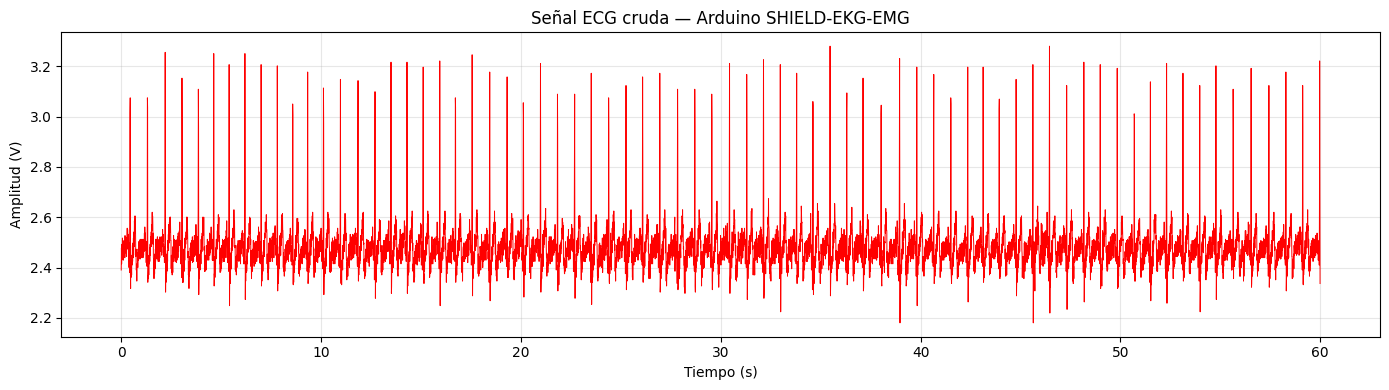

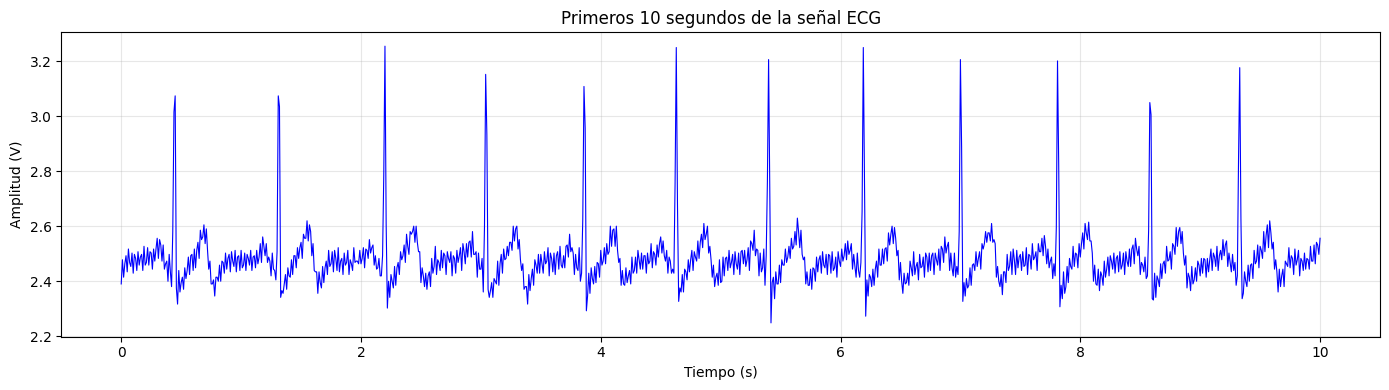

In [14]:
# Importar las librerías necesarias
import numpy as np              # Para operaciones matemáticas y manejo de arrays
import matplotlib.pyplot as plt # Para graficar
import neurokit2 as nk          # Para limpiar la señal y detectar picos R
from ecgdetectors import Detectors  # Para el algoritmo Pan-Tompkins y WQRS

# ============================================================
# PARÁMETROS DE ADQUISICIÓN
# ============================================================
fs = 100  # Frecuencia de muestreo en Hz (1000ms / delay de 10ms = 100 Hz)

# ============================================================
# CARGAR LA SEÑAL ECG
# ============================================================
# Los datos están en voltios (rango aprox 2.2 - 3.3 V)
# np.loadtxt lee el archivo línea por línea
# skiprows=1 salta la primera línea ya que tiene encabezado

ecg_raw = np.loadtxt('datos_ecg.txt', skiprows=1)

# Crear el eje de tiempo en segundos
t = np.arange(len(ecg_raw)) / fs

print(f"Muestras totales : {len(ecg_raw)}")
print(f"Duración total   : {t[-1]:.2f} segundos")
print(f"Valor mínimo (V) : {ecg_raw.min():.4f}")
print(f"Valor máximo (V) : {ecg_raw.max():.4f}")

# ============================================================
# VISUALIZAR LA SEÑAL CRUDA COMPLETA
# ============================================================
plt.figure(figsize=(14, 4))
plt.plot(t, ecg_raw, color='red', linewidth=0.7)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.title('Señal ECG cruda — Arduino SHIELD-EKG-EMG')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZAR SOLO LOS PRIMEROS 10 SEGUNDOS
# ============================================================
# Esto permite ver mejor la forma de onda del ECG
mask_10s = t <= 10
plt.figure(figsize=(14, 4))
plt.plot(t[mask_10s], ecg_raw[mask_10s], color='blue', linewidth=0.8)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.title('Primeros 10 segundos de la señal ECG')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

[NeuroKit2]    Picos R detectados: 71
[Pan-Tompkins] Picos R detectados: 71
[WQRS]         Picos R detectados: 75


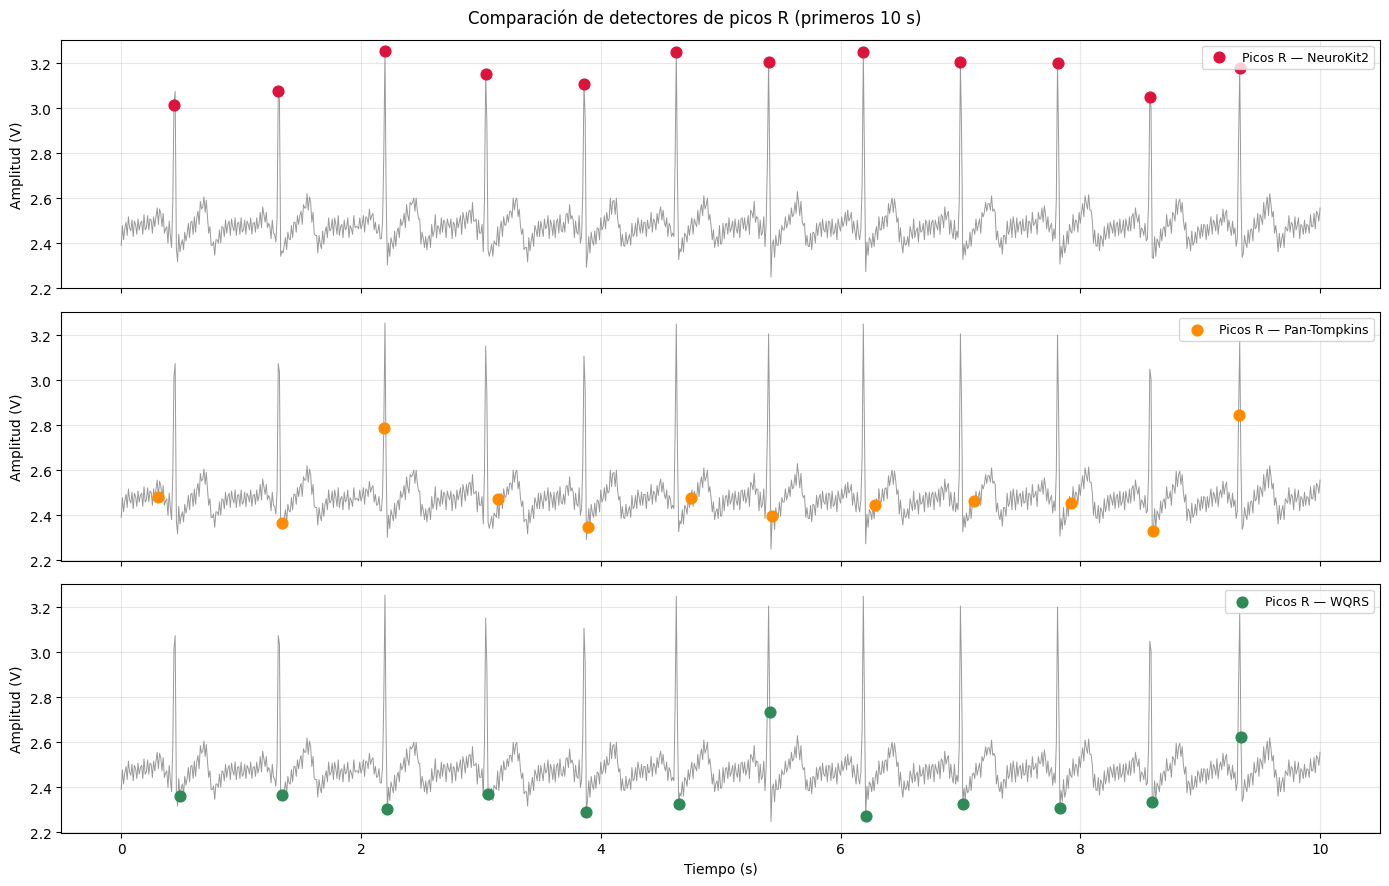

In [15]:
# DETECCIÓN DE PICOS R
# Comparamos NeuroKit2 vs Pan-Tompkins vs WQRS
# ============================================================

# -------------------------------------------------------
# MÉTODO A: NeuroKit2
# -------------------------------------------------------
# ecg_clean limpia la señal automáticamente:
# elimina ruido de alta frecuencia y deriva de línea base
ecg_clean_nk = nk.ecg_clean(ecg_raw, sampling_rate=fs)

# ecg_peaks detecta los picos R sobre la señal limpia
# retorna los índices exactos donde está cada pico R
signals_nk, info_nk = nk.ecg_peaks(ecg_clean_nk, sampling_rate=fs)
r_peaks_nk = info_nk['ECG_R_Peaks']
print(f"[NeuroKit2]    Picos R detectados: {len(r_peaks_nk)}")

# -------------------------------------------------------
# MÉTODO B: Pan-Tompkins
# -------------------------------------------------------
# Algoritmo clásico de 1985, el más citado en la literatura
# Usa filtrado, diferenciación y ventana integradora
det = Detectors(fs)
r_peaks_pan = det.pan_tompkins_detector(ecg_raw)
print(f"[Pan-Tompkins] Picos R detectados: {len(r_peaks_pan)}")

# -------------------------------------------------------
# MÉTODO C: WQRS
# -------------------------------------------------------
# Usa umbral adaptativo basado en energía local de la señal
r_peaks_wqrs = det.wqrs_detector(ecg_raw)
print(f"[WQRS]         Picos R detectados: {len(r_peaks_wqrs)}")

# -------------------------------------------------------
# VISUALIZACIÓN COMPARATIVA — Primeros 10 segundos
# -------------------------------------------------------
mask_10s = t <= 10

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

detectores = [
    (r_peaks_nk,   'NeuroKit2',    'crimson'),
    (r_peaks_pan,  'Pan-Tompkins', 'darkorange'),
    (r_peaks_wqrs, 'WQRS',         'seagreen'),
]

for ax, (peaks, nombre, color) in zip(axes, detectores):
    # Graficar señal cruda de fondo
    ax.plot(t[mask_10s], ecg_raw[mask_10s],
            color='gray', linewidth=0.7, alpha=0.8)

    # Filtrar picos dentro de los primeros 10 segundos
    peaks_visibles = [p for p in peaks if p < len(t) and t[p] <= 10]

    # Marcar los picos R detectados
    ax.scatter(t[peaks_visibles], ecg_raw[peaks_visibles],
               color=color, s=60, zorder=5, label=f'Picos R — {nombre}')

    ax.set_ylabel('Amplitud (V)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Tiempo (s)')
plt.suptitle('Comparación de detectores de picos R (primeros 10 s)', fontsize=12)
plt.tight_layout()
plt.show()

   MÉTRICAS BÁSICAS DE HRV
  Intervalos RR calculados : 70
  RR promedio              : 838.3 ms
  Frecuencia cardíaca      : 71.6 lpm
  SDNN                     : 35.75 ms
  RR mínimo                : 750.0 ms
  RR máximo                : 930.0 ms


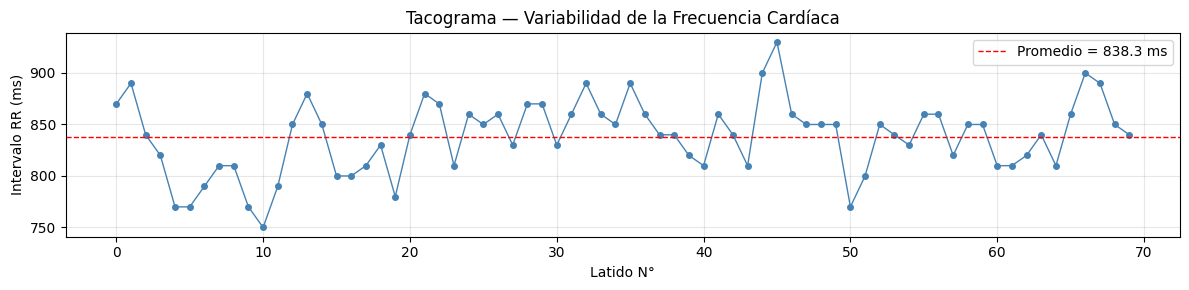

In [16]:
# Calcular intervalos RR
# -------------------------------------------------------
# np.diff calcula la diferencia entre índices consecutivos
# resultado en muestras → convertir a milisegundos
rr_muestras = np.diff(r_peaks_nk)
rr_ms = (rr_muestras / fs) * 1000.0

print("=" * 45)
print("   MÉTRICAS BÁSICAS DE HRV")
print("=" * 45)
print(f"  Intervalos RR calculados : {len(rr_ms)}")
print(f"  RR promedio              : {np.mean(rr_ms):.1f} ms")
print(f"  Frecuencia cardíaca      : {60000/np.mean(rr_ms):.1f} lpm")
print(f"  SDNN                     : {np.std(rr_ms, ddof=1):.2f} ms")
print(f"  RR mínimo                : {np.min(rr_ms):.1f} ms")
print(f"  RR máximo                : {np.max(rr_ms):.1f} ms")

# -------------------------------------------------------
# Visualizar el tacograma
# -------------------------------------------------------
# El tacograma muestra cómo varía el intervalo entre latidos.
# Una variación normal indica buen funcionamiento del
# sistema nervioso autónomo.
plt.figure(figsize=(12, 3))
plt.plot(rr_ms, 'o-', color='steelblue', linewidth=1, markersize=4)
plt.axhline(np.mean(rr_ms), color='red', linestyle='--',
            linewidth=1, label=f'Promedio = {np.mean(rr_ms):.1f} ms')
plt.xlabel('Latido N°')
plt.ylabel('Intervalo RR (ms)')
plt.title('Tacograma — Variabilidad de la Frecuencia Cardíaca')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# MÉTRICAS HRV COMPLETAS DOMINIO DEL TIEMPO
# Equivalente a get_time_domain_features() de hrvanalysis
# Implementadas manualmente con numpy
# ============================================================

# -------------------------------------------------------
# Diferencias entre intervalos RR sucesivos
# Necesarias para calcular RMSSD, SDSD, pNN50, pNN20
# -------------------------------------------------------
diff_rr = np.diff(rr_ms)   # RR[i+1] - RR[i] para todo i

# -- SDNN ------------------------------------------------
# Desviación estándar de todos los RR
# Refleja la variabilidad global del ritmo cardíaco
sdnn = np.std(rr_ms, ddof=1)

# -- RMSSD -----------------------------------------------
# Raíz cuadrática media de diferencias sucesivas
# Principal índice de actividad parasimpática (nervio vago)
rmssd = np.sqrt(np.mean(diff_rr ** 2))

# -- SDSD ------------------------------------------------
# Desviación estándar de las diferencias sucesivas
sdsd = np.std(diff_rr, ddof=1)

# -- pNN50 -----------------------------------------------
# % de diferencias sucesivas que superan 50 ms
# Índice vagal, normal en reposo: 10-40%
nn50  = np.sum(np.abs(diff_rr) > 50)
pnn50 = (nn50 / len(diff_rr)) * 100

# -- pNN20 -----------------------------------------------
# Igual que pNN50 pero con umbral de 20 ms
# Más sensible en registros cortos
nn20  = np.sum(np.abs(diff_rr) > 20)
pnn20 = (nn20 / len(diff_rr)) * 100

# -- ESTADÍSTICAS DE RR ----------------------------------
mean_rr   = np.mean(rr_ms)
median_rr = np.median(rr_ms)
range_rr  = np.max(rr_ms) - np.min(rr_ms)

# -- FRECUENCIA CARDÍACA ---------------------------------
# Se calcula para cada latido individualmente
fc = 60000 / rr_ms
mean_hr = np.mean(fc)
max_hr  = np.max(fc)
min_hr  = np.min(fc)
std_hr  = np.std(fc, ddof=1)

# -- COEFICIENTES DE VARIACIÓN ---------------------------
# Normalizan la variabilidad respecto a la media
cvnni = sdnn  / mean_rr   # SDNN / media RR
cvsd  = rmssd / mean_rr   # RMSSD / media RR

# -------------------------------------------------------
# IMPRIMIR TABLA DE RESULTADOS
# -------------------------------------------------------
print("=" * 62)
print("   CARACTERÍSTICAS HRV — DOMINIO DEL TIEMPO")
print("   (Equivalente a get_time_domain_features - hrvanalysis)")
print("=" * 62)
print(f"  mean_nni    = {mean_rr:>8.2f} ms   ← Media de intervalos RR")
print(f"  median_nni  = {median_rr:>8.2f} ms   ← Mediana de intervalos RR")
print(f"  range_nni   = {range_rr:>8.2f} ms   ← Rango (máx - mín) de RR")
print(f"  sdnn        = {sdnn:>8.2f} ms   ← Desv. estándar global de RR")
print(f"  sdsd        = {sdsd:>8.2f} ms   ← Desv. estándar de dif. sucesivas")
print(f"  rmssd       = {rmssd:>8.2f} ms   ← Índice vagal (actividad parasimpática)")
print(f"  nn50        = {nn50:>8d}       ← N° de dif. sucesivas > 50 ms")
print(f"  pnni_50     = {pnn50:>8.2f} %    ← % de dif. sucesivas > 50 ms")
print(f"  nn20        = {nn20:>8d}       ← N° de dif. sucesivas > 20 ms")
print(f"  pnni_20     = {pnn20:>8.2f} %    ← % de dif. sucesivas > 20 ms")
print(f"  cvnni       = {cvnni:>8.4f}       ← Coef. variación RR (SDNN/media)")
print(f"  cvsd        = {cvsd:>8.4f}       ← Coef. variación dif. (RMSSD/media)")
print(f"  mean_hr     = {mean_hr:>8.2f} lpm  ← Frecuencia cardíaca media")
print(f"  max_hr      = {max_hr:>8.2f} lpm  ← Frecuencia cardíaca máxima")
print(f"  min_hr      = {min_hr:>8.2f} lpm  ← Frecuencia cardíaca mínima")
print(f"  std_hr      = {std_hr:>8.2f} lpm  ← Desv. estándar de la FC")


   CARACTERÍSTICAS HRV — DOMINIO DEL TIEMPO
   (Equivalente a get_time_domain_features - hrvanalysis)
  mean_nni    =   838.29 ms   ← Media de intervalos RR
  median_nni  =   840.00 ms   ← Mediana de intervalos RR
  range_nni   =   180.00 ms   ← Rango (máx - mín) de RR
  sdnn        =    35.75 ms   ← Desv. estándar global de RR
  sdsd        =    34.96 ms   ← Desv. estándar de dif. sucesivas
  rmssd       =    34.70 ms   ← Índice vagal (actividad parasimpática)
  nn50        =        6       ← N° de dif. sucesivas > 50 ms
  pnni_50     =     8.70 %    ← % de dif. sucesivas > 50 ms
  nn20        =       37       ← N° de dif. sucesivas > 20 ms
  pnni_20     =    53.62 %    ← % de dif. sucesivas > 20 ms
  cvnni       =   0.0426       ← Coef. variación RR (SDNN/media)
  cvsd        =   0.0414       ← Coef. variación dif. (RMSSD/media)
  mean_hr     =    71.70 lpm  ← Frecuencia cardíaca media
  max_hr      =    80.00 lpm  ← Frecuencia cardíaca máxima
  min_hr      =    64.52 lpm  ← Frecuenc

**Nota:** La librería hrvanalysis no presenta compatibilidad con Python 3.11, versión instalada en el equipo de trabajo. Por esta razón, las métricas definidas en la función get_time_domain_features fueron implementadas manualmente siguiendo las definiciones estándar del Task Force of the European Society of Cardiology (1996), obteniendo resultados equivalentes. [9]

### **5.5 Aplicaciones clínicas del uso de ECG y EMG**
#### _Aplicaciones clínicas de ECG:_
- **Monitorización fetal (cardiotocografía)**

<u>Tipo de registro:</u> ECG fetal no invasivo (fECG) mediante electrodos abdominales en la madre, o invasivo mediante electrodo en cuero cabelludo fetal durante el parto. La frecuencia cardíaca fetal normal es de 110–160 lpm.

<u>Procesamiento utilizado:</u> El mayor desafío es separar el fECG del ECG materno (MECG), que lo supera en amplitud. Se emplean técnicas de cancelación adaptativa (filtros LMS), análisis de componentes independientes (ICA) y descomposición en valores singulares (SVD). Sobre la señal extraída se calcula la variabilidad de la FC fetal (fHRV) como indicador de bienestar fetal y posible hipoxia. [3]

- **Detección de fibrilación auricular en wearables**

<u>Tipo de registro:</u> ECG de derivación única (lead I) registrado con electrodos secos integrados en smartwatches (Apple Watch Series 4+, Fitbit Sense) o parches adhesivos (AliveCor KardiaMobile). Registros episódicos de 30 s a 5 min activados por el usuario o de forma continua (PPG con confirmación por ECG).

<u>Procesamiento utilizado:</u> Detección de la ausencia de onda P y de la irregularidad de los intervalos RR. Se utilizan algoritmos de aprendizaje profundo (CNN, LSTM) entrenados en bases de datos como PhysioNet/Computing in Cardiology Challenge. El Apple Watch utiliza una red neuronal validada clínicamente que clasifica el ritmo como sinusal, FA o no concluyente. La sensibilidad reportada supera el 98% para FA persistente. [4]

- **Marcapasos y desfibriladores implantables (ICD)**

<u>Tipo de registro:</u> ECG intracardíaco registrado en tiempo real mediante electrodos del electrodo de estimulación implantado en cavidades cardíacas (ventrículo derecho, aurícula derecha, ventrículo izquierdo en terapia de resincronización). Señales de amplitud mV con ancho de banda 10–400 Hz.

<u>Procesamiento utilizado:</u> El dispositivo analiza continuamente la morfología del electrograma intracardíaco y los intervalos RR. Ante detección de taquicardia ventricular (TV) o fibrilación ventricular (FV), aplica terapias escalonadas: estimulación antitaquicardia (ATP), cardioversión sincronizada o choque de desfibrilación (hasta 40 J). Algoritmos de discriminación SVT/VT evitan terapias inapropiadas. Los ICD modernos incluyen transmisión remota de datos (telemedicina cardíaca). [5]

#### _Aplicaciones clínicas de EMG:_
- **Interfaces cerebro-computador basadas en EMG (BCI periférico)**

<u>Tipo de registro:</u> sEMG multicanal se registra en músculos del antebrazo, el muñón o la cara. Para esto, se utilizan electrodos secos dispuestos en forma de malla, como por ejemplo el Myo Armband, que tiene electrodos en una cuadrícula de alta densidad. El ancho de banda es de 20 a 500 Hz y la frecuencia de muestreo es de al menos 1000 Hz.

<u>Procesamiento utilizado:</u> Se extraen características en el dominio del tiempo (RMS, MAV, varianza, zero-crossing rate, waveform length) y la frecuencia (densidad espectral de potencia). Un clasificador (LDA, SVM, red neuronal profunda) mapea el patrón de activación muscular a una intención de movimiento o comando. En EMG de alta densidad (HD-EMG) se aplica descomposición de señal para identificar potenciales de unidad motora individuales y decodificar la descarga neuronal con mayor precisión. [6]

- **Análisis de disfagia con EMG submentoniana**

<u>Tipo de registro:</u> sEMG superficial de los músculos suprahioideos (milohioideo, geniohioideo, digástrico vientre anterior) mediante electrodos colocados en la región submentoniana. Se sincroniza con videofluoroscopia o fibroendoscopia de la deglución (FEES) como gold standard. Registro de episodios discretos de deglución de agua, semisólidos y sólidos.

<u>Procesamiento utilizado:</u> Detección del inicio y fin de la activación muscular durante la fase oral y faríngea de la deglución (onset detection con umbral adaptativo). Se analiza la duración, amplitud pico y área bajo la curva de la envolvente RMS como indicadores del esfuerzo deglutorio. En rehabilitación se usa biofeedback visual en tiempo real para entrenamiento de la deglución supraglótica y maniobra de Mendelsohn. La disminución de amplitud o el retraso en el inicio son marcadores de disfagia neurogénica. [7]

- **Robótica colaborativa y exoesqueletos**

<u>Tipo de registro:</u> sEMG multicanal sobre músculos agonistas y antagonistas del miembro a asistir (bíceps/tríceps para exoesqueleto de codo; cuádriceps/isquiotibiales para exoesqueleto de rodilla). Integrado con sensores inerciales (IMU) para fusión de datos. Registro continuo durante la tarea motora.

<u>Procesamiento utilizado:</u> La intención de movimiento se estima en tiempo real a partir del sEMG mediante modelos de regresión (para control continuo de posición o fuerza) o clasificadores de patrones (para modos discretos). Se estima el torque muscular a partir de modelos musculoesqueléticos que relacionan la envolvente EMG con la fuerza producida. En rehabilitación post-ACV, el exoesqueleto amplifica el intento de movimiento voluntario del paciente (trigger-based assist-as-needed), promoviendo la neuroplasticidad. Se usan controladores adaptativos para compensar la fatiga muscular detectada por el desplazamiento espectral del EMG. [8]

### **5.6 Análisis de resultados y conclusiones**

#### _Análisis_

La señal electrocardiográfica fue registrada durante 60 segundos a una frecuencia de muestreo de 100 Hz, obteniendo 6000 muestras con una amplitud entre 2.18 V y 3.28 V. Este rango corresponde al voltaje de salida del módulo SHIELD-EKG-EMG de Olimex, el cual superpone la señal diferencial del ECG sobre un nivel de referencia de aproximadamente 2.5 V. La morfología de la señal cruda mostró picos R claramente identificables y periódicos a lo largo de todo el registro, lo que indica una buena calidad de la adquisición y un contacto electrodo-piel adecuado.

Se compararon tres algoritmos de detección de picos R: NeuroKit2, Pan-Tompkins y WQRS. NeuroKit2 fue el único que detectó correctamente los picos R, marcando consistentemente los máximos de cada complejo QRS a lo largo de los 10 segundos visualizados, con un total de 71 picos R detectados en el registro completo. Por el contrario, Pan-Tompkins y WQRS presentaron un desempeño deficiente, detectando puntos en valles y zonas intermedias de la señal en lugar de los picos R reales.
Este resultado se explica por el offset de voltaje presente en la señal (~2.5 V): Pan-Tompkins y WQRS fueron diseñados para señales ECG clínicas centradas en cero (rango típico ±2 mV), por lo que su umbral de detección no se adapta correctamente a señales con un nivel DC elevado. NeuroKit2, en cambio, aplica un preprocesamiento automático que incluye filtrado pasa-banda y eliminación de la deriva de línea base antes de la detección, lo que le permite identificar correctamente los picos independientemente del nivel de voltaje de la señal [10].

A partir de los 71 picos R detectados por NeuroKit2 se calcularon 70 intervalos RR y se extrajeron las características del dominio del tiempo equivalentes a la función get_time_domain_features de la librería hrvanalysis, siguiendo las definiciones del estándar Task Force [9]. 

La frecuencia cardíaca media de 71.7 lpm es consistente con los valores de referencia para mujeres jóvenes en reposo, cuyo rango normal es de 60–100 lpm [11]. El SDNN de 35.75 ms y el RMSSD de 34.70 ms indican una variabilidad cardíaca adecuada para un registro de corta duración (1 minuto); valores inferiores a 50 ms en registros de esta duración son considerados normales y no indican disfunción autonómica [9]. El pNN50 de 8.70% es bajo pero esperable en registros cortos, ya que esta métrica es más informativa en registros de 24 horas (Holter). El tacograma mostró fluctuaciones naturales alrededor del promedio sin valores atípicos extremos, lo que confirma un ritmo sinusal regular con variabilidad fisiológica normal.

#### _Conclusiones_

1. La adquisición de señales ECG con el módulo SHIELD-EKG-EMG y Arduino UNO permitió obtener un registro de calidad suficiente para el análisis. Durante la práctica se registró una señal ECG de 60 segundos en una sujeto femenina de 20 años en reposo, obteniendo una señal con picos R claramente visibles y periódicos. Esto demostró que sistemas de bajo costo pueden ser útiles para la adquisición de biopotenciales en entornos académicos, siempre que se realice una correcta preparación de la piel y ubicación de los electrodos.

2. De los tres algoritmos evaluados, NeuroKit2 fue el único que detectó correctamente los picos R en la señal registrada. Pan-Tompkins y WQRS fallaron debido al offset de voltaje (~2.5 V) característico de la salida del módulo SHIELD-EKG-EMG, mientras que NeuroKit2 manejó esto correctamente gracias a su preprocesamiento automático. Esto evidencia que la elección del algoritmo de detección debe considerar las características específicas del sistema de adquisición utilizado y no solo el desempeño reportado en la literatura con señales clínicas ideales.

3. Los valores de HRV obtenidos confirmaron que la sujeto presentaba un ritmo cardíaco normal durante el registro. La frecuencia cardíaca media fue de 71.7 lpm, el RMSSD de 34.70 ms y el SDNN de 35.75 ms, todos dentro de los rangos esperados para una mujer joven en reposo. El tacograma mostró variaciones naturales entre latidos sin irregularidades, lo que indica que el sistema nervioso autónomo estaba funcionando normalmente durante la sesión de registro.

4. La frecuencia de muestreo de 100 Hz representa una limitación del sistema para el análisis de HRV. Aunque cumple con el criterio de Nyquist para las frecuencias de interés del ECG (hasta ~40 Hz), la resolución temporal de 10 ms por muestra limita la precisión en la localización exacta de los picos R y por ende introduce un error de cuantización en los intervalos RR. Los estándares clínicos recomiendan frecuencias de muestreo de al menos 250–500 Hz para análisis de HRV precisos. Esta limitación es inherente al sistema de bajo costo utilizado y debe considerarse al interpretar los resultados.

### **Referencias**

[1] Webster, J. G. (Ed.). (2009). Medical instrumentation: Application and design (4th ed.). John Wiley & Sons.

[2] De Luca, C. J., Gilmore, L. D., Kuznetsov, M., & Roy, S. H. (2010). Filtering the surface EMG signal: Movement artifact and baseline noise contamination. Journal of Biomechanics, 43(8), 1573–1579. https://doi.org/10.1016/j.jbiomech.2010.01.027

[3] Clifford, G. D., Silva, I., Behar, J., & Moody, G. B. (2014). Non-invasive fetal ECG analysis. Physiological Measurement, 35(8), 1521–1536. https://doi.org/10.1088/0967-3334/35/8/1521

[4] Perez, M. V., Mahaffey, K. W., Hedlin, H., et al. (2019). Large-scale assessment of a smartwatch to identify atrial fibrillation. New England Journal of Medicine, 381(20), 1909–1917. https://doi.org/10.1056/NEJMoa1901183

[5] Epstein, A. E., DiMarco, J. P., Ellenbogen, K. A., et al. (2008). ACC/AHA/HRS 2008 guidelines for device-based therapy of cardiac rhythm abnormalities. Journal of the American College of Cardiology, 51(21), e1–e62. https://doi.org/10.1016/j.jacc.2008.02.032

[6] Parajuli, N., Sreenivasan, N., Bifulco, P., Cesarelli, M., Savino, S., Niola, V., Esposito, D., Hamilton, T. J., Naik, G. R., Gunawardana, U., & Gargiulo, G. D. (2019). Real-time EMG based pattern recognition control for hand prostheses: A review on existing methods, challenges and future implementation. Sensors, 19(20), 4596. https://doi.org/10.3390/s19204596

[7] Vaiman, M. (2007). Standardization of surface electromyography utilized to evaluate patients with dysphagia. European Archives of Oto-Rhino-Laryngology, 264(8), 967–973. https://pmc.ncbi.nlm.nih.gov/articles/PMC1904196/

[8] Lyu, M., Chen, W. H., Ding, X., Wang, J., Pei, Z., & Zhang, B. (2019). Development of an EMG-controlled knee exoskeleton to assist home rehabilitation in a game context. Frontiers in Neurorobotics, 13, 67. https://doi.org/10.3389/fnbot.2019.00067

[9] Task Force of the European Society of Cardiology. (1996). Heart rate variability: Standards of measurement, physiological interpretation, and clinical use. Circulation, 93(5), 1043–1065. https://doi.org/10.1161/01.CIR.93.5.1043

[10] Makowski, D., Pham, T., Lau, Z. J., Brammer, J. C., Lespinasse, F., Pham, H., Schölzel, C., & Chen, S. A. (2021). NeuroKit2: A Python toolbox for neurophysiological signal processing. Behavior Research Methods, 53(4), 1689–1696. https://doi.org/10.3758/s13428-020-01516-y

[11] Ostchega, Y., Porter, K. S., Hughes, J., Dillon, C. F., & Nwankwo, T. (2011). Resting pulse rate reference data for children, adolescents, and adults: United States, 1999–2008. National Health Statistics Reports, 41, 1–16. https://www.cdc.gov/nchs/data/nhsr/nhsr041.pdf